In [39]:
import pandas as pd
Input_Space = pd.read_excel('Input_Space.xlsx',engine='openpyxl')
#type(Input_Space)
#del Input_Space['BLOC_1']
#del Input_Space['BLOC_2']
Input_Space

,RM_1,RM_2,RM_3,RM_4,BLOC_1,BLOC_2,PR_temp,PR_speed
0,0.5,4.0,3.5,10,18,28,23,50
1,1.0,0.5,5.0,15,18,28,18,40
2,1.5,1.0,2.0,7,18,28,25,70
3,2.0,1.5,3.5,10,18,28,30,25
4,3.5,2.0,0.5,9,18,28,23,80
5,0.5,0.5,1.0,12,18,28,27,90
6,1.0,1.0,1.5,10,18,28,18,50
7,1.5,1.5,2.0,13,18,28,32,40
8,2.0,2.0,5.0,14,18,28,30,70
9,3.5,3.5,4.0,7,18,28,23,25


# Filtrer les  données avec la Variance

In [40]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold() # Threshold default is 0
_ = vt.fit(Input_Space)
var_vector_mask = vt.get_support()
#var_vector_mask 
Input_Space = Input_Space.loc[:, var_vector_mask]
col_names=Input_Space.columns
len(col_names)
Input_Space

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed
0,0.5,4.0,3.5,10,23,50
1,1.0,0.5,5.0,15,18,40
2,1.5,1.0,2.0,7,25,70
3,2.0,1.5,3.5,10,30,25
4,3.5,2.0,0.5,9,23,80
5,0.5,0.5,1.0,12,27,90
6,1.0,1.0,1.5,10,18,50
7,1.5,1.5,2.0,13,32,40
8,2.0,2.0,5.0,14,30,70
9,3.5,3.5,4.0,7,23,25


In [41]:
Output_Space = pd.read_excel('Output_Space.xlsx',engine='openpyxl')
Output_Space

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,128.0,25000,6.920819,67.480662,1,2,2,100.0,649.5
1,137.5,27625,11.792500,16.582639,1,1,3,25.0,546.0
2,55.0,39250,4.110698,54.859325,1,2,3,75.0,1009.0
3,120.5,48875,6.890253,99.770620,0,3,3,92.5,23.5
4,72.0,56500,6.259637,13.420144,0,1,5,85.0,1245.5
5,9.5,31625,9.440692,70.877713,1,3,2,35.0,1377.0
6,37.0,27250,6.500000,64.223469,0,2,3,47.5,737.5
7,74.5,45875,10.103749,50.865358,1,2,3,75.0,289.0
8,178.0,48500,10.756962,89.468562,1,3,4,95.0,929.0
9,188.5,55375,3.785819,98.781719,0,3,4,100.0,147.0


# Creation du dataset avec 6 nouvelles variables de input_Space par permutation

In [42]:
import numpy as np
Vars=col_names
Input_Space[[v + "_fake" for v in Vars]]=Input_Space.iloc[np.random.permutation(Input_Space.index)].reset_index(drop=True)
Input_Space
                                                           


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed,RM_1_fake,RM_2_fake,RM_3_fake,RM_4_fake,PR_temp_fake,PR_speed_fake
0,0.5,4.0,3.5,10,23,50,2.0,2.0,5.0,14,30,70
1,1.0,0.5,5.0,15,18,40,1.0,1.0,1.5,10,18,50
2,1.5,1.0,2.0,7,25,70,1.0,0.5,5.0,15,18,40
3,2.0,1.5,3.5,10,30,25,1.5,1.5,2.0,13,32,40
4,3.5,2.0,0.5,9,23,80,1.5,1.0,2.0,7,25,70
5,0.5,0.5,1.0,12,27,90,0.5,0.5,1.0,12,27,90
6,1.0,1.0,1.5,10,18,50,5.0,0.0,0.5,6,27,80
7,1.5,1.5,2.0,13,32,40,3.5,3.5,4.0,7,23,25
8,2.0,2.0,5.0,14,30,70,3.5,2.0,0.5,9,23,80
9,3.5,3.5,4.0,7,23,25,4.0,0.0,1.0,11,18,90


# Fonction permettant de comparer les variables avec leur fakes

In [43]:
def ft_from_fake(ft_input,var_names):
    ft=ft_input
    # print(ft)
    for i in var_names: 
        #print(ft.loc[i,'feature_importance_vals'])
        if  ft.loc[i,'feature_importance_vals'] <= ft.loc[i+"_fake",'feature_importance_vals']:
            ft.loc[i,'feature_importance_vals']=0
          
    ft.drop(ft.tail(len(col_names)).index,inplace = True)
    
    return ft

# Random Forest model and SHAP for Cost prediction

In [44]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y1 = Output_Space.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y1) 
import shap
##### SHAP explaination
shap_values1 = shap.TreeExplainer(model).shap_values(X)

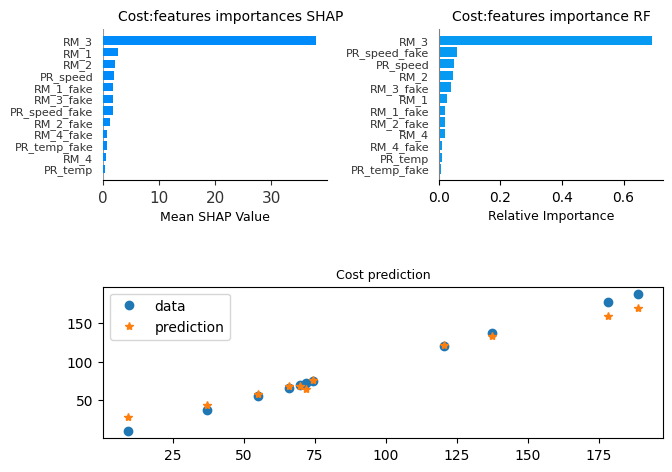

In [46]:
########################################### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
##################### Visualisation data predict
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values1, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Cost:features importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Cost:features importance RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y1.iloc[1:12],Y1.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y1.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Cost prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Cost.png')

In [47]:
vals1= np.abs(shap_values1).mean(0)
feature_importance1 = pd.DataFrame(list(zip(X,vals1)),columns=['col_name','feature_importance_vals'])
feature_importance1.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance1=feature_importance1.set_index('col_name',drop=True)
feature_importance1

,feature_importance_vals
col_name,
RM_1,2.623601
RM_2,2.162022
RM_3,37.992712
RM_4,0.606258
PR_temp,0.397453
PR_speed,1.920443
RM_1_fake,1.864337
RM_2_fake,1.189831
RM_3_fake,1.850540


In [48]:
ft_from_fake(feature_importance1,col_names)
feature_importance1.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)

,feature_importance_vals
col_name,
RM_4,0.000000
PR_temp,0.000000
PR_speed,1.920443
RM_2,2.162022
RM_1,2.623601
RM_3,37.992712


Text(0.5, 0, 'Mean SHAP Value')

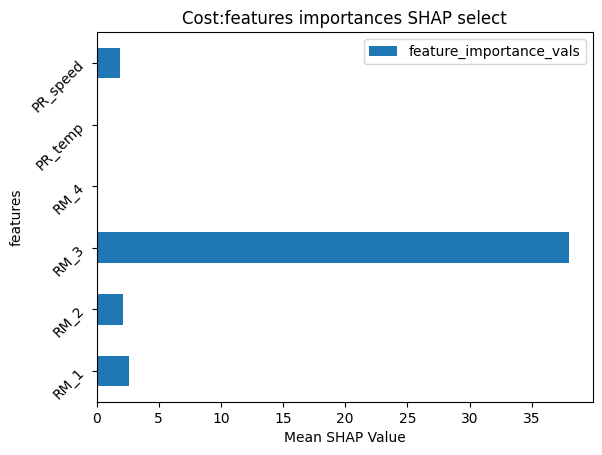

In [49]:
# Get the Horizontal bar
feature_importance1.plot(kind='barh', rot=45)
plt.title("Cost:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")


# Random Forest model and SHAP for Visco prediction

In [50]:
##################### Random Forest application
Y2 = Output_Space.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y2) 
##### SHAP explaination
import shap
shap_values2 = shap.TreeExplainer(model).shap_values(X)


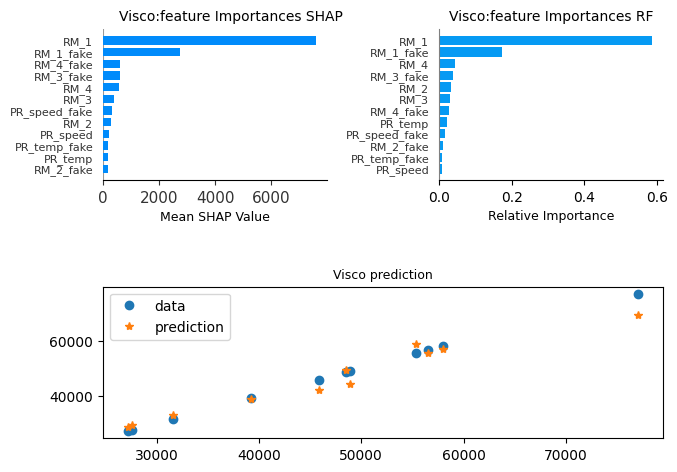

In [13]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values2, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Visco:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Visco:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y2.iloc[1:12],Y2.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y2.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Visco prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Visco.png')

In [51]:
vals2= np.abs(shap_values2).mean(0)
feature_importance2 = pd.DataFrame(list(zip(X,vals2)),columns=['col_name','feature_importance_vals'])
feature_importance2.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance2=feature_importance2.set_index('col_name',drop=True)
feature_importance2

,feature_importance_vals
col_name,
RM_1,9541.144213
RM_2,280.807851
RM_3,476.988657
RM_4,432.869131
PR_temp,141.638168
PR_speed,390.069391
RM_1_fake,364.071032
RM_2_fake,492.062809
RM_3_fake,66.131096


In [52]:
ft_from_fake(feature_importance2,col_names)
feature_importance2.reset_index()

,col_name,feature_importance_vals
0,RM_1,9541.144213
1,RM_2,0.000000
2,RM_3,476.988657
3,RM_4,432.869131
4,PR_temp,0.000000
5,PR_speed,390.069391


Text(0.5, 0, 'Mean SHAP Value')

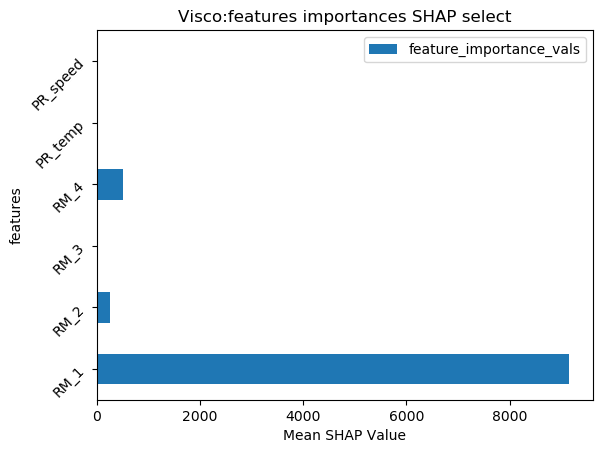

In [16]:
# Get the Horizontal bar
feature_importance2.plot(kind='barh', rot=45)
plt.title("Visco:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")


# Random Forest model and SHAP for Ph prediction

In [53]:
##################### Random Forest application
Y3 = Output_Space.loc[:,'Ph'].astype(float)  
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y3) 
mean_mse, std_mse = np.mean(Score), np.std(Score)
##### SHAP explaination
import shap
shap_values3 = shap.TreeExplainer(model).shap_values(X)

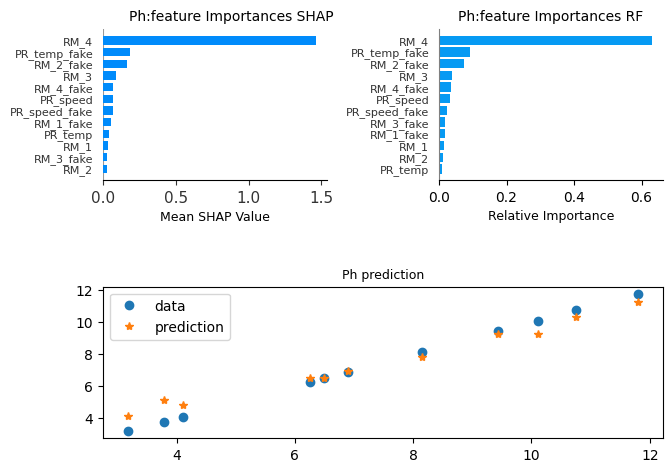

In [16]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values3, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Ph:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Ph:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y3.iloc[1:12],Y3.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y3.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Ph prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Ph.png')

In [54]:
vals3= np.abs(shap_values3).mean(0)
feature_importance3 = pd.DataFrame(list(zip(X,vals3)),columns=['col_name','feature_importance_vals'])
feature_importance3.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance3=feature_importance3.set_index('col_name',drop=True)
feature_importance3

,feature_importance_vals
col_name,
RM_1,0.034925
RM_2,0.017375
RM_3,0.114457
RM_4,1.867654
PR_temp,0.024012
PR_speed,0.088937
RM_1_fake,0.028935
RM_2_fake,0.031116
RM_3_fake,0.020263


In [55]:
ft_from_fake(feature_importance3,col_names)
feature_importance3.reset_index()

,col_name,feature_importance_vals
0,RM_1,0.034925
1,RM_2,0.000000
2,RM_3,0.114457
3,RM_4,1.867654
4,PR_temp,0.000000
5,PR_speed,0.088937


Text(0.5, 0, 'Mean SHAP Value')

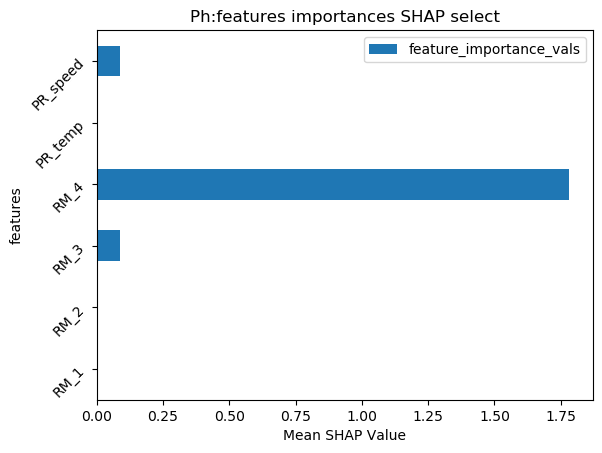

In [22]:
# Get the Horizontal bar
feature_importance3.plot(kind='barh', rot=45)
plt.title("Ph:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Rheo prediction¶

In [56]:
##################### Random Forest application
Y4 =Output_Space.loc[:,'Rheo'].astype(float)
X = Input_Space
# 10*Output_Space.loc[:,'Rheo'].astype(float)
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y4) 
import shap
##### SHAP explaination
shap_values4 = shap.TreeExplainer(model).shap_values(X)

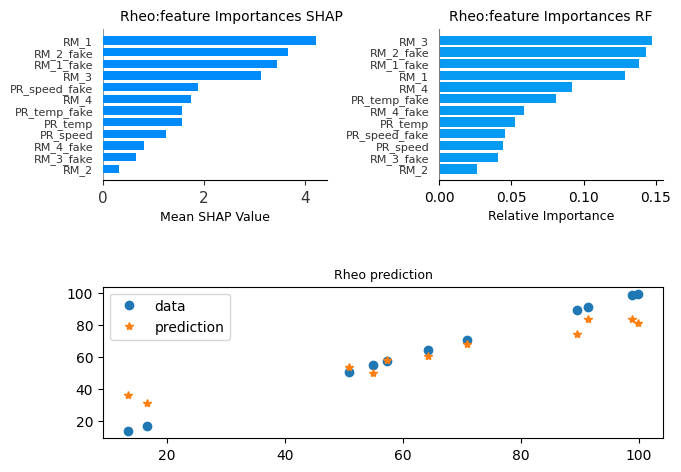

In [20]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values4, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Rheo:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Rheo:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y4.iloc[1:12],Y4.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y4.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Rheo prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Rheo.png')

In [57]:
vals4= np.abs(shap_values4).mean(0)
feature_importance4 = pd.DataFrame(list(zip(X,vals4)),columns=['col_name','feature_importance_vals'])
feature_importance4.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance4=feature_importance4.set_index('col_name',drop=True)
feature_importance4

,feature_importance_vals
col_name,
RM_1,4.444636
RM_2,0.320759
RM_3,2.121406
RM_4,2.477760
PR_temp,0.807279
PR_speed,1.668089
RM_1_fake,3.760957
RM_2_fake,1.524117
RM_3_fake,0.671379


In [58]:
ft_from_fake(feature_importance4,col_names)
feature_importance4.reset_index()

,col_name,feature_importance_vals
0,RM_1,4.444636
1,RM_2,0.000000
2,RM_3,2.121406
3,RM_4,2.477760
4,PR_temp,0.000000
5,PR_speed,1.668089


Text(0.5, 0, 'Mean SHAP Value')

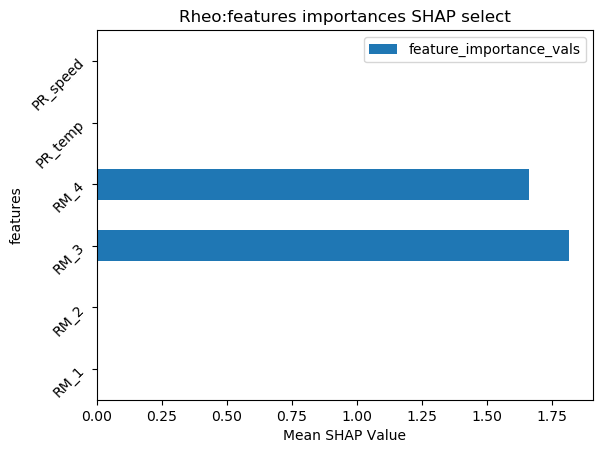

In [33]:
# Get the Horizontal bar
feature_importance4.plot(kind='barh', rot=45)
plt.title("Rheo:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Stability prediction

In [59]:
##################### Random Forest application
Y5 = Output_Space.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y5) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5 = shap.TreeExplainer(model).shap_values(X)


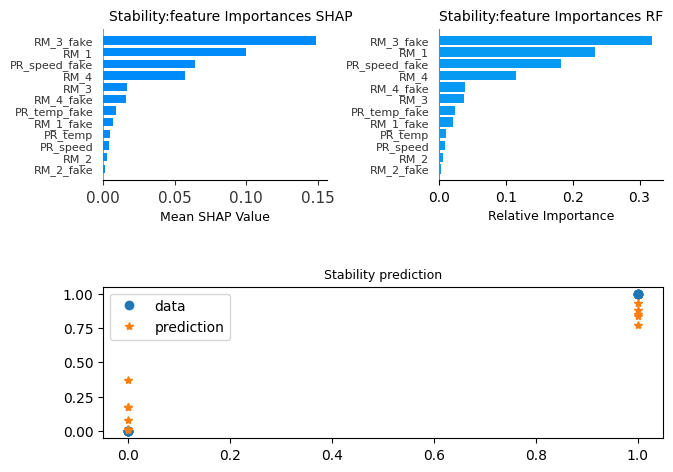

In [24]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values5, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Stability:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Stability:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y5.iloc[1:12],Y5.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y5.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Stability prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)

#plt.show()
plt.savefig('latex/shap_dummy_Stability.png')

In [60]:
vals5= np.abs(shap_values5).mean(0)
feature_importance5 = pd.DataFrame(list(zip(X,vals5)),columns=['col_name','feature_importance_vals'])
feature_importance5.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance5=feature_importance5.set_index('col_name',drop=True)
feature_importance5

,feature_importance_vals
col_name,
RM_1,0.146557
RM_2,0.004028
RM_3,0.063732
RM_4,0.109160
PR_temp,0.007604
PR_speed,0.014036
RM_1_fake,0.017903
RM_2_fake,0.019848
RM_3_fake,0.016798


In [61]:
ft_from_fake(feature_importance5,col_names)
feature_importance5.reset_index()

,col_name,feature_importance_vals
0,RM_1,0.146557
1,RM_2,0.000000
2,RM_3,0.063732
3,RM_4,0.109160
4,PR_temp,0.000000
5,PR_speed,0.014036


Text(0.5, 0, 'Mean SHAP Value')

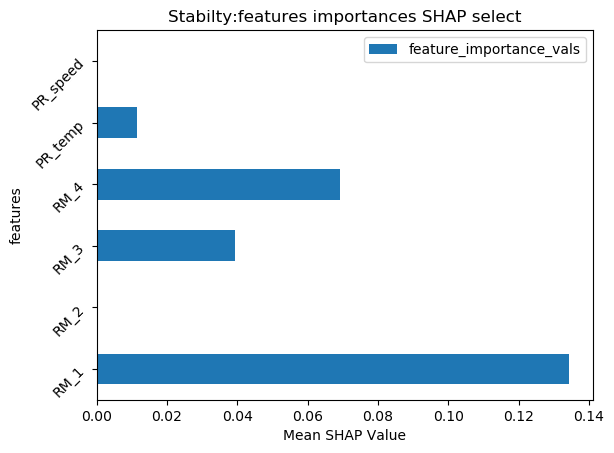

In [38]:
# Get the Horizontal bar
feature_importance5.plot(kind='barh', rot=45)
plt.title("Stabilty:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Texture prediction

In [62]:
##################### Random Forest application
Y6 = Output_Space.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y6) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6 = shap.TreeExplainer(model).shap_values(X)


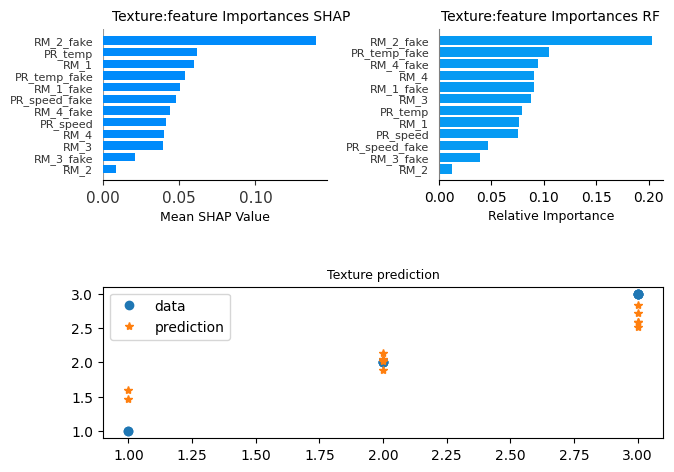

In [29]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values6, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Texture:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Texture:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y6.iloc[1:12],Y6.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y6.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Texture prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Texture.png')

In [63]:
vals6= np.abs(shap_values6).mean(0)
feature_importance6 = pd.DataFrame(list(zip(X,vals6)),columns=['col_name','feature_importance_vals'])
feature_importance6.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance6=feature_importance6.set_index('col_name',drop=True)
feature_importance6

,feature_importance_vals
col_name,
RM_1,0.053527
RM_2,0.008789
RM_3,0.035796
RM_4,0.062418
PR_temp,0.041945
PR_speed,0.056436
RM_1_fake,0.051669
RM_2_fake,0.024309
RM_3_fake,0.040640


In [64]:
ft_from_fake(feature_importance6,col_names)
feature_importance6.reset_index()

,col_name,feature_importance_vals
0,RM_1,0.053527
1,RM_2,0.000000
2,RM_3,0.000000
3,RM_4,0.062418
4,PR_temp,0.000000
5,PR_speed,0.056436


Text(0.5, 0, 'Mean SHAP Value')

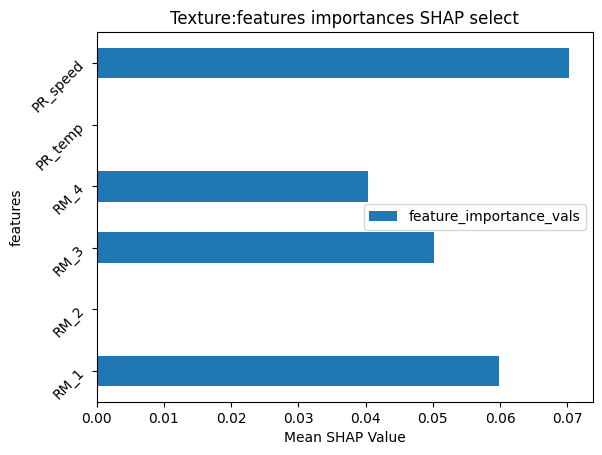

In [47]:
# Get the Horizontal bar
feature_importance6.plot(kind='barh', rot=45)
plt.title("Texture:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Senso1 prediction

In [65]:
##################### Random Forest application
Y7 = Output_Space.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y7) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7 = shap.TreeExplainer(model).shap_values(X)


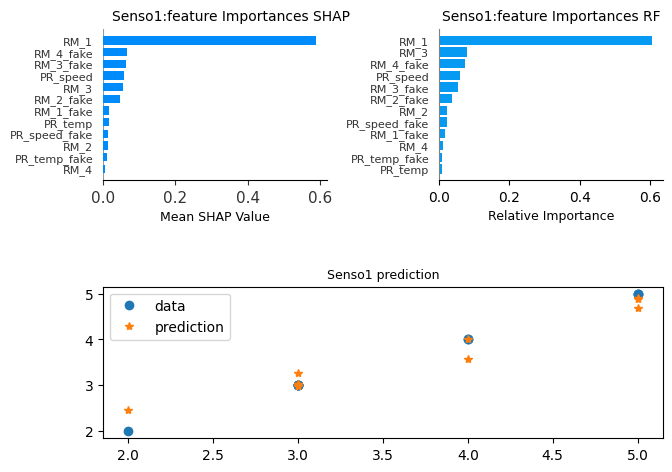

In [34]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values7, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Senso1:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Senso1:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y7.iloc[1:12],Y7.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y7.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Senso1 prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Senso1.png')

In [66]:
vals7= np.abs(shap_values7).mean(0)
feature_importance7 = pd.DataFrame(list(zip(X,vals7)),columns=['col_name','feature_importance_vals'])
feature_importance7.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance7=feature_importance7.set_index('col_name',drop=True)
feature_importance7

,feature_importance_vals
col_name,
RM_1,0.619095
RM_2,0.024083
RM_3,0.055158
RM_4,0.008956
PR_temp,0.013048
PR_speed,0.064322
RM_1_fake,0.015555
RM_2_fake,0.017746
RM_3_fake,0.021233


In [67]:
ft_from_fake(feature_importance7,col_names)
feature_importance7.reset_index()

,col_name,feature_importance_vals
0,RM_1,0.619095
1,RM_2,0.024083
2,RM_3,0.055158
3,RM_4,0.000000
4,PR_temp,0.000000
5,PR_speed,0.064322


Text(0.5, 0, 'Mean SHAP Value')

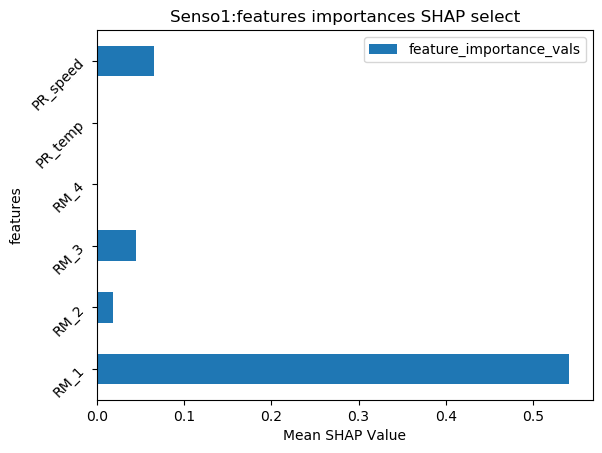

In [48]:
# Get the Horizontal bar
feature_importance7.plot(kind='barh', rot=45)
plt.title("Senso1:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Naturality prediction

In [68]:
##################### Random Forest application
Y8 = Output_Space.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y8) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8 = shap.TreeExplainer(model).shap_values(X)

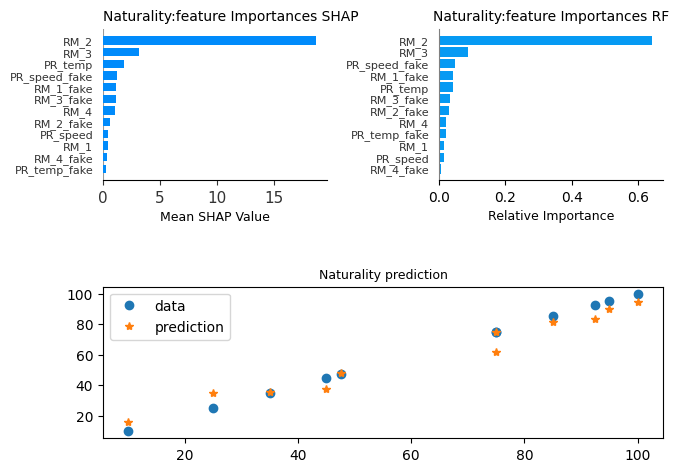

In [41]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values8, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Naturality:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Naturality:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y8.iloc[1:12],Y8.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y8.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Naturality prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Naturality.png')

In [69]:
vals8= np.abs(shap_values8).mean(0)
feature_importance8 = pd.DataFrame(list(zip(X,vals8)),columns=['col_name','feature_importance_vals'])
feature_importance8.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance8=feature_importance8.set_index('col_name',drop=True)
feature_importance8

,feature_importance_vals
col_name,
RM_1,0.436208
RM_2,20.176313
RM_3,3.216869
RM_4,1.600134
PR_temp,1.592630
PR_speed,0.179437
RM_1_fake,0.361719
RM_2_fake,0.329001
RM_3_fake,0.279631


In [70]:
ft_from_fake(feature_importance8,col_names)
feature_importance8.reset_index()

,col_name,feature_importance_vals
0,RM_1,0.436208
1,RM_2,20.176313
2,RM_3,3.216869
3,RM_4,1.600134
4,PR_temp,1.592630
5,PR_speed,0.000000


Text(0.5, 0, 'Mean SHAP Value')

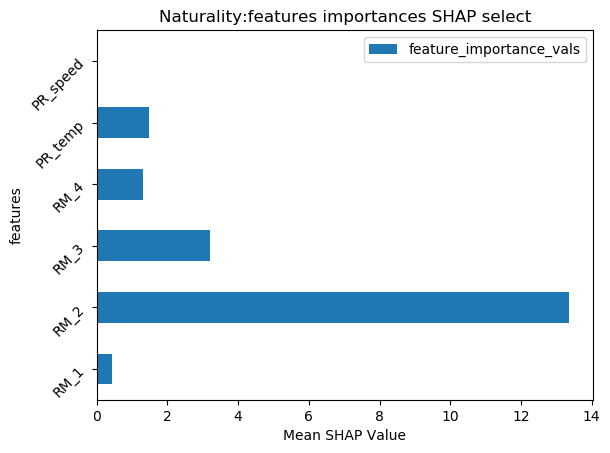

In [53]:
# Get the Horizontal bar
feature_importance8.plot(kind='barh', rot=45)
plt.title("Naturality:features importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

# Random Forest model and SHAP for Microbio30days prediction¶

In [71]:
##################### Random Forest application
Y9 = Output_Space.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y9) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9 = shap.TreeExplainer(model).shap_values(X)

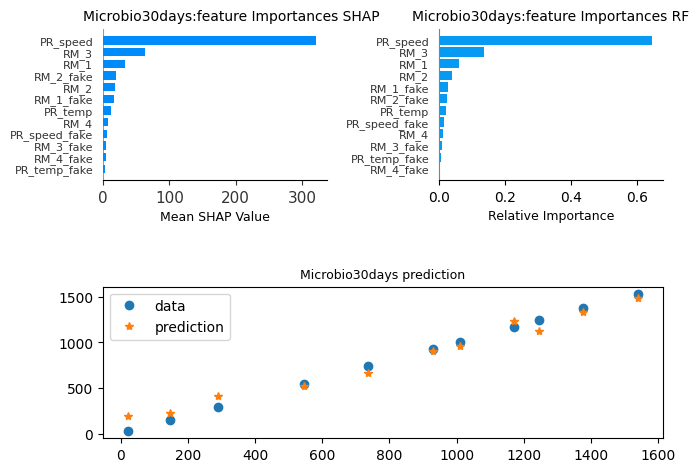

In [46]:
##################### Visualisation data predict
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
## feature importance SHAP
plt.subplot(221)
#features = X.columns
shap.summary_plot(shap_values9, X, plot_type="bar",show=0,sort=True)
plt.yticks(fontsize=8,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=9)
plt.suptitle("Microbio30days:feature Importances SHAP",y=0.78,x=0.36,fontsize=10)
## feature importance RandomForest
plt.subplot(222)
features = X.columns
plt.title('Microbio30days:feature Importances RF',fontsize=10)
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=9)
### Visualisation data predict
plt.subplot(212)
plt.plot (Y9.iloc[1:12],Y9.iloc[1:12,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(Y9.iloc[1:12],model.predict(X.iloc[1:12,]) , '*',label="prediction")
plt.title ("Microbio30days prediction",fontsize=9) # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.2,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.75, 
                    wspace=0.5, 
                    hspace=0.7)
#plt.show()
plt.savefig('latex/shap_dummy_Microbio30days.png')

In [72]:
vals9= np.abs(shap_values9).mean(0)
feature_importance9 = pd.DataFrame(list(zip(X,vals9)),columns=['col_name','feature_importance_vals'])
feature_importance9.sort_values(by=['feature_importance_vals'],ascending=False,inplace=False)
feature_importance9=feature_importance9.set_index('col_name',drop=True)
feature_importance9

,feature_importance_vals
col_name,
RM_1,34.962893
RM_2,19.696462
RM_3,61.172399
RM_4,6.411416
PR_temp,9.094413
PR_speed,317.964297
RM_1_fake,3.280423
RM_2_fake,3.683687
RM_3_fake,4.369973


In [73]:
ft_from_fake(feature_importance9,col_names)
feature_importance9.reset_index()

,col_name,feature_importance_vals
0,RM_1,34.962893
1,RM_2,19.696462
2,RM_3,61.172399
3,RM_4,6.411416
4,PR_temp,0.000000
5,PR_speed,317.964297


Text(0.5, 0, 'Mean SHAP Value')

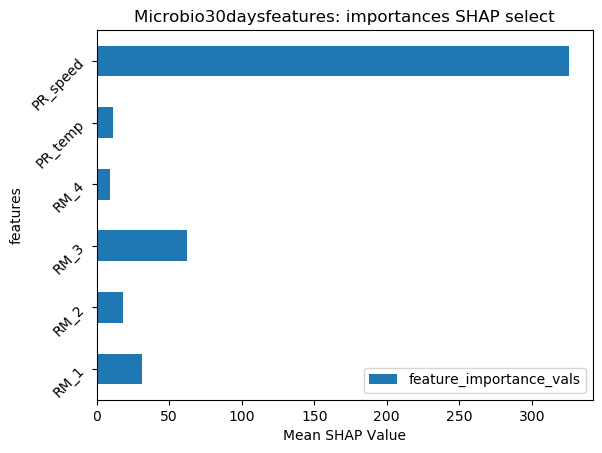

In [61]:
# Get the Horizontal bar
feature_importance9.plot(kind='barh', rot=45)
plt.title("Microbio30daysfeatures: importances SHAP select")
plt.ylabel("features")
plt.xlabel("Mean SHAP Value")

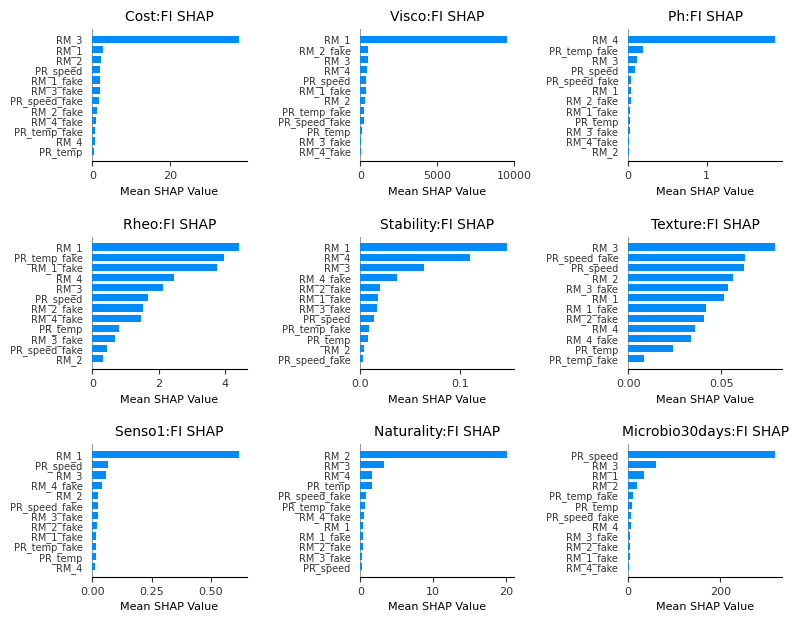

In [95]:
######################## feature importance SHAP
fig = plt.figure(figsize = (200, 200))
sub1 = fig.add_subplot(331) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Cost:FI SHAP',fontsize=10) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values1, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(332)
sub2.set_title('Visco:FI SHAP',fontsize=10)
shap.summary_plot(shap_values2, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(333)
sub3.set_title('Ph:FI SHAP',fontsize=10)
shap.summary_plot(shap_values3, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(334)
sub4.set_title('Rheo:FI SHAP',fontsize=10)
shap.summary_plot(shap_values4, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Rheo:feature Importances SHAP")
sub5 = fig.add_subplot(335)
sub5.set_title('Stability:FI SHAP',fontsize=10)
shap.summary_plot(shap_values5, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Stability:feature Importances SHAP")
sub6 = fig.add_subplot(336)
sub6.set_title('Texture:FI SHAP',fontsize=10)
shap.summary_plot(shap_values6, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Texture:feature Importances SHAP")
sub7 = fig.add_subplot(337)
sub7.set_title('Senso1:FI SHAP',fontsize=10)
shap.summary_plot(shap_values7, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#sub7.plt.suptitle("Senso1:feature Importances SHAP")
sub8 = fig.add_subplot(338)
sub8.set_title('Naturality:FI SHAP',fontsize=10)
shap.summary_plot(shap_values8, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Naturality:feature Importances SHAP")
sub9 = fig.add_subplot(339)
sub9.set_title('Microbio30days:FI SHAP',fontsize=10)
shap.summary_plot(shap_values9, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Microbio30days:feature Importances SHAP")
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1.5, 
                    hspace=2)
plt.tight_layout(pad=1,h_pad=1.5)
#plt.show()
plt.savefig('latex/shap_fakes_Resume.png')

# Résumer de Shap importance avec effet seuil

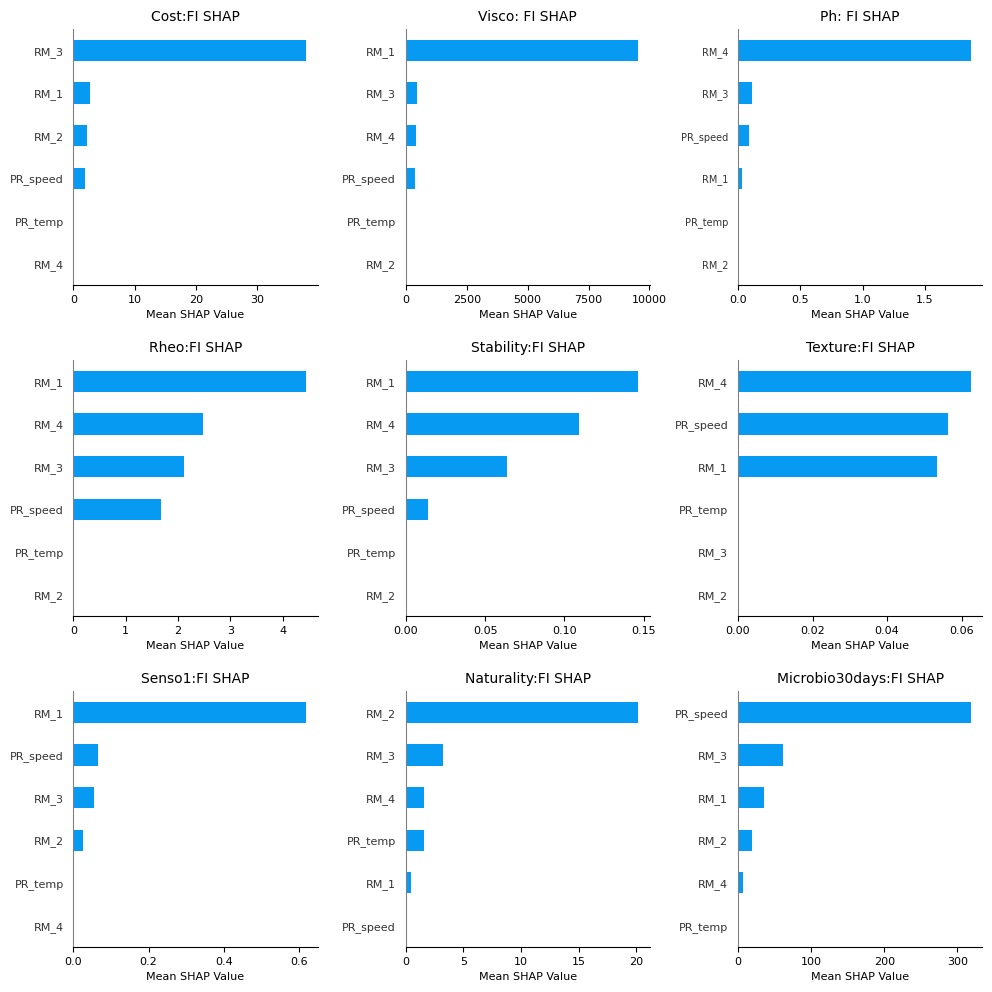

In [96]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(331) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Cost:FI SHAP',fontsize=10) # non OOP: plt.title('The function f')
#features = X.columns
feature_importance1["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance1["feature_importance_vals"].sort_values(),color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(332)
sub2.set_title('Visco: FI SHAP',fontsize=10)
feature_importance2["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance2["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Visco:feature Importances SHAP")
sub3 = fig.add_subplot(333)
sub3.set_title('Ph: FI SHAP',fontsize=10)
feature_importance3["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance3["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Ph:feature Importances SHAP")
sub4 = fig.add_subplot(334)
sub4.set_title('Rheo:FI SHAP',fontsize=10)
feature_importance4["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance4["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Rheo:feature Importances SHAP")
sub5 = fig.add_subplot(335)
sub5.set_title('Stability:FI SHAP',fontsize=10)
feature_importance5["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance5["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Stability:feature Importances SHAP")
sub6 = fig.add_subplot(336)
sub6.set_title('Texture:FI SHAP',fontsize=10)
feature_importance6["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance6["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Texture:feature Importances SHAP")
sub7 = fig.add_subplot(337)
sub7.set_title('Senso1:FI SHAP',fontsize=10)
feature_importance7["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance7["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#sub7.plt.suptitle("Senso1:feature Importances SHAP")
sub8 = fig.add_subplot(338)
sub8.set_title('Naturality:FI SHAP',fontsize=10)
feature_importance8["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance8["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Naturality:feature Importances SHAP")
sub9 = fig.add_subplot(339)
sub9.set_title('Microbio30days:FI SHAP',fontsize=10)
feature_importance9["feature_importance_vals"].sort_values().plot(kind='barh',color='#069AF3')
#plt.barh(col_names,feature_importance9["feature_importance_vals"],color='#069AF3', align='center')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.ylabel('')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Microbio30days:feature Importances SHAP")
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1.5, 
                    hspace=2)
plt.tight_layout(pad=1,h_pad=1.5)
#plt.show()
plt.savefig('latex/shap_fake_Resume_seuil.png')

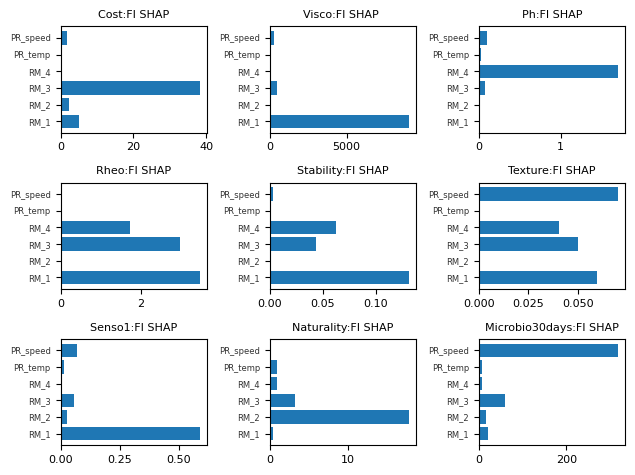

In [46]:
import matplotlib.pyplot as plt
######################## feature importance SHAP
#plt.suptitle("Tous mes graphes", fontsize=16) #Affiche un titre pour la figure
plt.subplot(331)
plt.barh(col_names,feature_importance1["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Cost:FI SHAP",fontsize=8)
plt.subplot(332)
plt.barh(col_names,feature_importance2["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Visco:FI SHAP ",fontsize=8)
plt.subplot(333)
plt.barh(col_names,feature_importance3["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Ph:FI SHAP",fontsize=8)
plt.subplot(334)
plt.barh(col_names,feature_importance4["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Rheo:FI SHAP",fontsize=8)
plt.subplot(335)
plt.barh(col_names,feature_importance5["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Stability:FI SHAP",fontsize=8)
plt.subplot(336)
plt.barh(col_names,feature_importance6["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Texture:FI SHAP",fontsize=8)
plt.subplot(337)
plt.barh(col_names,feature_importance7["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Senso1:FI SHAP",fontsize=8)
plt.subplot(338)
plt.barh(col_names,feature_importance8["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Naturality:FI SHAP",fontsize=8)
plt.subplot(339)
plt.barh(col_names,feature_importance9["feature_importance_vals"])
plt.xticks(fontsize=8)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Microbio30days:FI SHAP",fontsize=8)
#plt.suptitle("Microbio30days:feature Importances SHAP")
plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=0.8)
plt.tight_layout(pad=0.9,h_pad=1)
#plt.show()
plt.savefig('latex/shap_dummy_Resume.png')

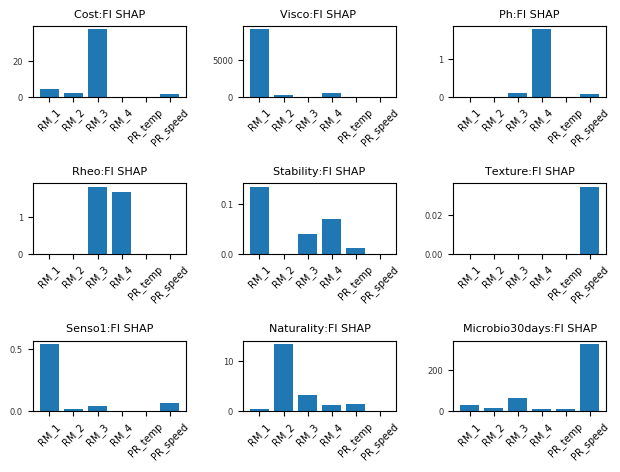

In [109]:
import matplotlib.pyplot as plt
######################## feature importance SHAP
#plt.suptitle("Tous mes graphes", fontsize=16) #Affiche un titre pour la figure
plt.subplot(331)
plt.bar(col_names,feature_importance1["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Cost:FI SHAP",fontsize=8)
plt.subplot(332)
plt.bar(col_names,feature_importance2["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Visco:FI SHAP ",fontsize=8)
plt.subplot(333)
plt.bar(col_names,feature_importance3["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Ph:FI SHAP",fontsize=8)
plt.subplot(334)
plt.bar(col_names,feature_importance4["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Rheo:FI SHAP",fontsize=8)
plt.subplot(335)
plt.bar(col_names,feature_importance5["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Stability:FI SHAP",fontsize=8)
plt.subplot(336)
plt.bar(col_names,feature_importance6["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Texture:FI SHAP",fontsize=8)
plt.subplot(337)
plt.bar(col_names,feature_importance7["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Senso1:FI SHAP",fontsize=8)
plt.subplot(338)
plt.bar(col_names,feature_importance8["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Naturality:FI SHAP",fontsize=8)
plt.subplot(339)
plt.bar(col_names,feature_importance9["feature_importance_vals"])
plt.xticks(fontsize=7,rotation=45)
plt.yticks(fontsize=6,color ='0.2')
plt.title("Microbio30days:FI SHAP",fontsize=8)
#plt.suptitle("Microbio30days:feature Importances SHAP")
plt.subplots_adjust(left=0.2,
                    bottom=0.5, 
                    right=1, 
                    top=0.9, 
                    wspace=1, 
                    hspace=0.8)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()